# Stage 3 — Primera evaluación held-out cíclica

Este notebook consume por primera vez una partición test del toy cíclico. La receta, seeds, tamaños y gates fueron congelados tras el PASS multi-seed de desarrollo.

La barrera es obligatoria: reentrenamos usando sólo train/validation y exigimos reproducir el resumen congelado con tolerancia `1e-8`. Test se materializa sólo después del replay. El resultado held-out se reporta una vez y sus umbrales no se modificarán.

In [1]:
# ruff: noqa: E402, E501, I001
import json
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display

from koopman_jepa.config import DataConfig, ExperimentConfig, ModelConfig, TrainConfig, validate_config
from koopman_jepa.model import TemporalJEPA
from koopman_jepa.phase_analysis import evaluate_phase_operator_diagnostics, evaluate_phase_representation
from koopman_jepa.phase_data import PhaseWindowConfig, make_phase_tensor_dataset_splits
from koopman_jepa.training import collect_paired_embeddings, evaluate_model_loss, select_device, set_seed, train_model

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
REFERENCE_PATH = ROOT / "configs" / "stage3_cyclic_multiseed_development.yaml"
CONFIG_PATH = ROOT / "configs" / "stage3_cyclic_heldout.yaml"
with REFERENCE_PATH.open(encoding="utf-8") as handle:
    reference_raw = yaml.safe_load(handle)
with CONFIG_PATH.open(encoding="utf-8") as handle:
    raw = yaml.safe_load(handle)
normalized = {key: value for key, value in raw.items() if key != "validation_replay"}
normalized = json.loads(json.dumps(normalized))
test_repeats_per_transition = normalized["splits"].pop("test_repeats_per_transition")
assert test_repeats_per_transition == 64
assert normalized == reference_raw
seeds = raw["seeds"]
emission_config = PhaseWindowConfig(**raw["emission"], repeats_per_transition=1)
model_raw = raw["model"]
print(json.dumps({"config": CONFIG_PATH.name, "seeds": seeds, "test_repeats_per_transition": test_repeats_per_transition, "test_consumed": False}, indent=2))

{
  "config": "stage3_cyclic_heldout.yaml",
  "seeds": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10
  ],
  "test_repeats_per_transition": 64,
  "test_consumed": false
}


In [3]:
def make_experiment_config(seed):
    config = ExperimentConfig(
        data=DataConfig(context_length=emission_config.window_length),
        model=ModelConfig(latent_dim=model_raw["latent_dim"], channels=model_raw["channels"], predictor_init=model_raw["predictor_init"]),
        train=TrainConfig(seed=seed, **raw["train"]),
    )
    validate_config(config)
    return config

def make_model(device):
    return TemporalJEPA(
        latent_dim=model_raw["latent_dim"],
        channels=model_raw["channels"],
        predictor_init=model_raw["predictor_init"],
        pooling=model_raw["pooling"],
        input_length=emission_config.window_length,
    ).to(device)

def evaluate_split(model, train_dataset, evaluation_dataset, baseline_loss, experiment_config, seed):
    device = select_device(experiment_config.train.device)
    selected = evaluate_model_loss(model, evaluation_dataset, experiment_config, device)
    train_current, _, _, train_phase_pairs = collect_paired_embeddings(model, train_dataset, experiment_config.train.batch_size, device)
    evaluation_current, evaluation_future_online, evaluation_future_target, evaluation_phase_pairs = collect_paired_embeddings(model, evaluation_dataset, experiment_config.train.batch_size, device)
    predictor_matrix = model.predictor.matrix.detach().cpu().numpy()
    metrics = evaluate_phase_representation(
        train_current, train_phase_pairs[:, 0], evaluation_current, evaluation_phase_pairs[:, 0], predictor_matrix, raw["dynamics"], seed
    )
    diagnostics = evaluate_phase_operator_diagnostics(
        evaluation_current, evaluation_future_online, evaluation_future_target, evaluation_phase_pairs[:, 0], evaluation_phase_pairs[:, 1], predictor_matrix, raw["dynamics"]
    )
    loss_ratio = selected.loss / baseline_loss
    gate_config = raw["gates"]
    gate_checks = {
        "validation_improves": loss_ratio <= gate_config["maximum_validation_loss_ratio"],
        "embedding_scale": metrics["embedding_std_mean"] >= gate_config["minimum_embedding_std_mean"],
        "effective_rank": metrics["effective_rank"] >= gate_config["minimum_effective_rank"],
        "phase_probe": metrics["linear_probe_accuracy"] >= gate_config["minimum_linear_probe_accuracy"],
        "phase_alignment": metrics["phase_alignment_error"] <= gate_config["maximum_phase_alignment_error"],
        "active_rank": metrics["active_rank"] == gate_config["required_active_rank"],
        "intertwining": metrics["intertwining_error"] <= gate_config["maximum_intertwining_error"],
        "active_invariance": metrics["active_invariance_error"] is not None and metrics["active_invariance_error"] <= gate_config["maximum_active_invariance_error"],
        "spectrum": metrics["spectral_max_absolute_error"] is not None and metrics["spectral_max_absolute_error"] <= gate_config["maximum_spectral_error"],
    }
    return {
        "seed": seed,
        "passed": bool(all(gate_checks.values())),
        "failed_gates": [name for name, passed in gate_checks.items() if not passed],
        "loss_ratio": float(loss_ratio),
        "embedding_std_mean": metrics["embedding_std_mean"],
        "effective_rank": metrics["effective_rank"],
        "linear_probe_accuracy": metrics["linear_probe_accuracy"],
        "phase_alignment_error": metrics["phase_alignment_error"],
        "active_rank": metrics["active_rank"],
        "intertwining_error": metrics["intertwining_error"],
        "active_invariance_error": metrics["active_invariance_error"],
        "spectral_max_absolute_error": metrics["spectral_max_absolute_error"],
        "online_target_phase_basis_error": diagnostics["online_target_phase_basis_error"],
        "trained_online_endomorphism_error": diagnostics["trained_online_endomorphism_error"],
        "gate_checks": gate_checks,
    }

In [4]:
trained_runs = {}
validation_results = []
for seed in seeds:
    experiment_config = make_experiment_config(seed)
    splits = make_phase_tensor_dataset_splits(
        emission_config,
        train_repeats_per_transition=raw["splits"]["train_repeats_per_transition"],
        validation_repeats_per_transition=raw["splits"]["validation_repeats_per_transition"],
        seed=seed,
    )
    assert splits.test is None and splits.test_seed is None
    train_dataset = splits.train[raw["dynamics"]]
    validation_dataset = splits.validation[raw["dynamics"]]
    set_seed(seed)
    device = select_device(experiment_config.train.device)
    model = make_model(device)
    baseline = evaluate_model_loss(model, validation_dataset, experiment_config, device)
    history = train_model(model, train_dataset, validation_dataset, experiment_config, device)
    assert all(np.isfinite(value) for row in history for value in row.values())
    result = evaluate_split(model, train_dataset, validation_dataset, baseline.loss, experiment_config, seed)
    validation_results.append(result)
    trained_runs[seed] = {"model": model, "config": experiment_config, "train_dataset": train_dataset}

validation_summary = {
    "successful_seeds": sum(result["passed"] for result in validation_results),
    "median_validation_loss_ratio": float(np.median([result["loss_ratio"] for result in validation_results])),
    "median_effective_rank": float(np.median([result["effective_rank"] for result in validation_results])),
    "median_phase_alignment_error": float(np.median([result["phase_alignment_error"] for result in validation_results])),
    "median_intertwining_error": float(np.median([result["intertwining_error"] for result in validation_results])),
    "median_spectral_error": float(np.median([result["spectral_max_absolute_error"] for result in validation_results])),
}
replay_config = raw["validation_replay"]
tolerance = replay_config["absolute_tolerance"]
validation_replay_checks = {
    key: (actual == replay_config[key] if key == "successful_seeds" else bool(np.isclose(actual, replay_config[key], rtol=0.0, atol=tolerance)))
    for key, actual in validation_summary.items()
}
validation_replay_passed = bool(all(validation_replay_checks.values()))
print(json.dumps({"validation_summary": validation_summary, "validation_replay_checks": validation_replay_checks, "validation_replay_passed": validation_replay_passed, "test_consumed": False}, indent=2))
assert validation_replay_passed

epoch=001 train=4.215964 val=3.604055


epoch=012 train=1.869702 val=2.787130


epoch=024 train=0.982038 val=1.941588


epoch=036 train=0.566599 val=1.550434


epoch=048 train=0.394095 val=1.371254


...

epoch=012 train=0.738051 val=1.777359


epoch=024 train=0.454189 val=1.518585


epoch=036 train=0.371883 val=1.436641


epoch=048 train=0.359203 val=1.414144


epoch=060 train=0.336276 val=1.409114
{
  "validation_summary": {
    "successful_seeds": 8,
    "median_validation_loss_ratio": 0.301005565613913,
    "median_effective_rank": 2.810831580138041,
    "median_phase_alignment_error": 0.1522005143373802,
    "median_intertwining_error": 0.06822191509801676,
    "median_spectral_error": 0.06702866939299468
  },
  "validation_replay_checks": {
    "successful_seeds": true,
    "median_validation_loss_ratio": true,
    "median_effective_rank": true,
    "median_phase_alignment_error": true,
    "median_intertwining_error": true,
    "median_spectral_error": true
  },
  "validation_replay_passed": true,
  "test_consumed": false
}


In [5]:
heldout_results = []
for seed in seeds:
    heldout_splits = make_phase_tensor_dataset_splits(
        emission_config,
        train_repeats_per_transition=raw["splits"]["train_repeats_per_transition"],
        validation_repeats_per_transition=raw["splits"]["validation_repeats_per_transition"],
        seed=seed,
        test_repeats_per_transition=test_repeats_per_transition,
    )
    assert heldout_splits.test is not None
    assert heldout_splits.test_seed == seed + 37
    test_dataset = heldout_splits.test[raw["dynamics"]]
    run = trained_runs[seed]
    experiment_config = run["config"]
    device = select_device(experiment_config.train.device)
    set_seed(seed)
    initial_model = make_model(device)
    baseline = evaluate_model_loss(initial_model, test_dataset, experiment_config, device)
    result = evaluate_split(run["model"], run["train_dataset"], test_dataset, baseline.loss, experiment_config, seed)
    heldout_results.append(result)
    print(f"seed={seed:02d} heldout_pass={result['passed']} ratio={result['loss_ratio']:.3f} intertwining={result['intertwining_error']:.3f} spectrum={result['spectral_max_absolute_error']:.3f}")

successful_seeds = sum(result["passed"] for result in heldout_results)
median_intertwining_error = float(np.median([result["intertwining_error"] for result in heldout_results]))
median_spectral_error = float(np.median([result["spectral_max_absolute_error"] for result in heldout_results]))
aggregate_config = raw["aggregate_gates"]
aggregate_checks = {
    "successful_seeds": successful_seeds >= aggregate_config["minimum_successful_seeds"],
    "median_intertwining": median_intertwining_error <= aggregate_config["maximum_median_intertwining_error"],
    "median_spectrum": median_spectral_error <= aggregate_config["maximum_median_spectral_error"],
}
heldout_gate_passed = bool(all(aggregate_checks.values()))
heldout_summary = {
    "successful_seeds": successful_seeds,
    "total_seeds": len(heldout_results),
    "median_test_loss_ratio": float(np.median([result["loss_ratio"] for result in heldout_results])),
    "median_effective_rank": float(np.median([result["effective_rank"] for result in heldout_results])),
    "median_phase_alignment_error": float(np.median([result["phase_alignment_error"] for result in heldout_results])),
    "median_intertwining_error": median_intertwining_error,
    "median_spectral_error": median_spectral_error,
    "worst_intertwining_error": max(result["intertwining_error"] for result in heldout_results),
    "worst_spectral_error": max(result["spectral_max_absolute_error"] for result in heldout_results),
    "aggregate_checks": aggregate_checks,
    "heldout_gate_passed": heldout_gate_passed,
    "test_consumed": True,
}
print(json.dumps({"heldout_summary": heldout_summary, "heldout_results": heldout_results}, indent=2))

seed=01 heldout_pass=False ratio=0.650 intertwining=0.204 spectrum=0.302


seed=02 heldout_pass=False ratio=0.625 intertwining=0.039 spectrum=0.041


seed=03 heldout_pass=False ratio=0.538 intertwining=0.078 spectrum=0.076


seed=04 heldout_pass=False ratio=0.544 intertwining=0.059 spectrum=0.058


seed=05 heldout_pass=False ratio=0.629 intertwining=0.057 spectrum=0.052


seed=06 heldout_pass=False ratio=0.584 intertwining=0.387 spectrum=0.321


seed=07 heldout_pass=False ratio=0.714 intertwining=0.512 spectrum=0.379


seed=08 heldout_pass=False ratio=0.580 intertwining=0.083 spectrum=0.094


seed=09 heldout_pass=False ratio=0.546 intertwining=0.043 spectrum=0.045


seed=10 heldout_pass=False ratio=0.540 intertwining=0.053 spectrum=0.055
{
  "heldout_summary": {
    "successful_seeds": 0,
    "total_seeds": 10,
    "median_test_loss_ratio": 0.5815977917787114,
    "median_effective_rank": 2.8191772553190275,
    "median_phase_alignment_error": 0.15314130297661385,
    "median_intertwining_error": 0.06822191509801676,
    "median_spectral_error": 0.06702866939299468,
    "worst_intertwining_error": 0.5116221835198809,
    "worst_spectral_error": 0.37886467516894656,
    "aggregate_checks": {
      "successful_seeds": false,
      "median_intertwining": true,
      "median_spectrum": true
    },
    "heldout_gate_passed": false,
    "test_consumed": true
  },
  "heldout_results": [
    {
      "seed": 1,
      "passed": false,
      "failed_gates": [
        "validation_improves"
      ],
      "loss_ratio": 0.6500848078250915,
      "embedding_std_mean": 1.1924675650975674,
      "effective_rank": 2.8425216432291887,
      "linear_probe_accuracy": 

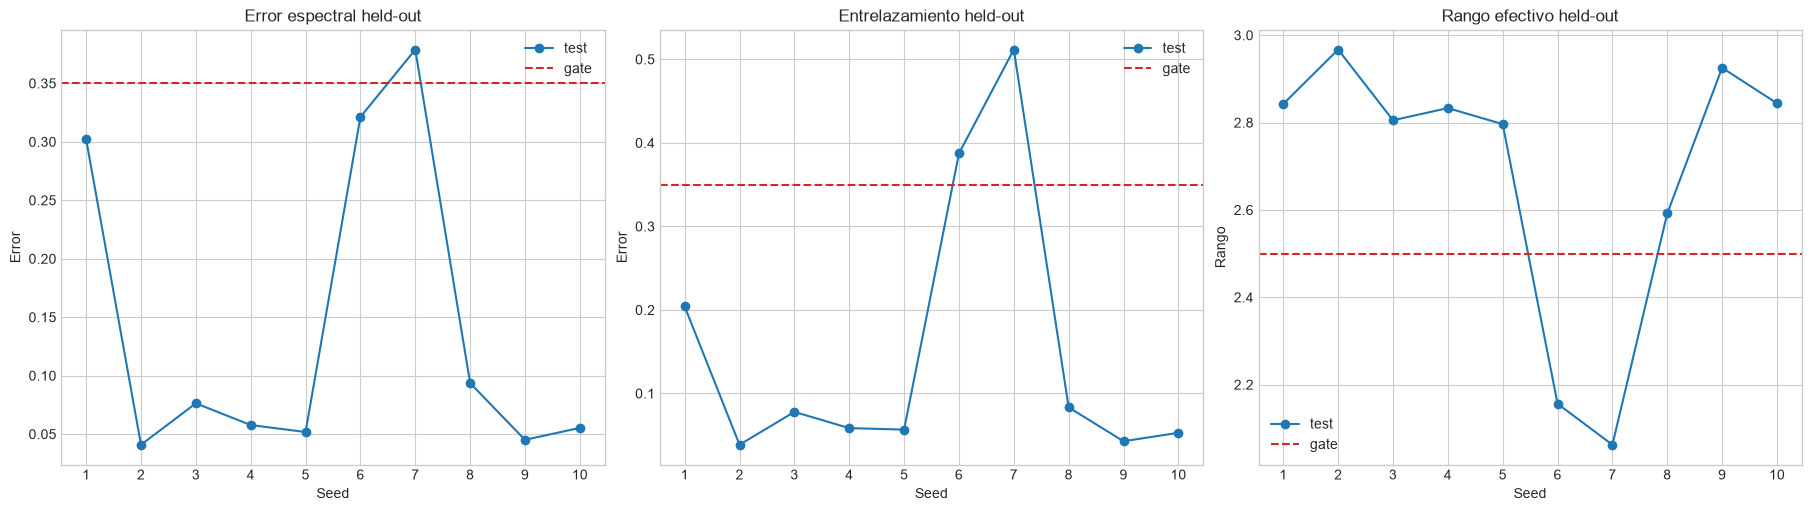

## Resultado held-out

- Replay de validation antes de test: **PASS**.
- Gate held-out: **FAIL**.
- Seeds exitosas: **0/10** (mínimo: `8`).
- Mediana test/baseline: **0.582**.
- Mediana rango efectivo / alineación: **2.819 / 0.153**.
- Mediana entrelazamiento / espectro: **0.068 / 0.067**.
- Peor entrelazamiento / espectro: **0.512 / 0.379**.
- Fallos individuales: **seed 1: validation_improves; seed 2: validation_improves; seed 3: validation_improves; seed 4: validation_improves; seed 5: validation_improves; seed 6: validation_improves, effective_rank, intertwining; seed 7: validation_improves, effective_rank, intertwining, spectrum; seed 8: validation_improves; seed 9: validation_improves; seed 10: validation_improves**.

Test quedó consumido para este protocolo. El resultado se conserva con los gates predeclarados, sea PASS o FAIL.


In [6]:
seed_axis = np.array(seeds)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
axes[0].plot(seed_axis, [result["spectral_max_absolute_error"] for result in heldout_results], marker="o", label="test")
axes[0].axhline(raw["gates"]["maximum_spectral_error"], color="tab:red", linestyle="--", label="gate")
axes[0].set(title="Error espectral held-out", xlabel="Seed", ylabel="Error", xticks=seed_axis)
axes[0].legend()

axes[1].plot(seed_axis, [result["intertwining_error"] for result in heldout_results], marker="o", label="test")
axes[1].axhline(raw["gates"]["maximum_intertwining_error"], color="tab:red", linestyle="--", label="gate")
axes[1].set(title="Entrelazamiento held-out", xlabel="Seed", ylabel="Error", xticks=seed_axis)
axes[1].legend()

axes[2].plot(seed_axis, [result["effective_rank"] for result in heldout_results], marker="o", label="test")
axes[2].axhline(raw["gates"]["minimum_effective_rank"], color="tab:red", linestyle="--", label="gate")
axes[2].set(title="Rango efectivo held-out", xlabel="Seed", ylabel="Rango", xticks=seed_axis)
axes[2].legend()
plt.show()

failed_description = "; ".join(f"seed {result['seed']}: {', '.join(result['failed_gates'])}" for result in heldout_results if not result["passed"]) or "ninguna"
display(Markdown(f"""## Resultado held-out

- Replay de validation antes de test: **PASS**.
- Gate held-out: **{'PASS' if heldout_gate_passed else 'FAIL'}**.
- Seeds exitosas: **{successful_seeds}/{len(heldout_results)}** (mínimo: `{aggregate_config['minimum_successful_seeds']}`).
- Mediana test/baseline: **{heldout_summary['median_test_loss_ratio']:.3f}**.
- Mediana rango efectivo / alineación: **{heldout_summary['median_effective_rank']:.3f} / {heldout_summary['median_phase_alignment_error']:.3f}**.
- Mediana entrelazamiento / espectro: **{median_intertwining_error:.3f} / {median_spectral_error:.3f}**.
- Peor entrelazamiento / espectro: **{heldout_summary['worst_intertwining_error']:.3f} / {heldout_summary['worst_spectral_error']:.3f}**.
- Fallos individuales: **{failed_description}**.

Test quedó consumido para este protocolo. El resultado se conserva con los gates predeclarados, sea PASS o FAIL.
"""))